# Imports and layer



In [ ]:
pip install torch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Parameter
import math

In [ ]:
# @title
class BayesLinear(nn.Module):

    def __init__(self,
                 in_features,
                 out_features,
                 bias = True,
                 weight_prior_mu = 0.,
                 weight_prior_sigma = 1.,
                 bias_prior_mu = 0.,
                 bias_prior_sigma = 1.):

        super(BayesLinear, self).__init__()

        self.samples = {'weights' : None, 'bias' : None}

        self.in_features = in_features
        self.out_features = out_features
        self.bias = bias
        self.weight_prior_mu = weight_prior_mu
        self.weight_prior_sigma = weight_prior_sigma
        self.l_weight_prior_sigma = torch.log(torch.tensor(weight_prior_sigma)) # take log of the sigma prior

        self.weights_mu = Parameter(torch.rand(out_features, in_features)-0.5) #initialize mu weights
        self.lweights_sigma = Parameter(torch.log(weight_prior_sigma*torch.ones(out_features, in_features))) # intialize log weights for sigma

        if self.bias:
            self.bias_prior_mu = bias_prior_mu
            self.bias_prior_sigma = bias_prior_sigma
            self.bias_mean = Parameter(torch.rand(out_features)-0.5) # intialize bias mean if given
            self.lbias_sigma = Parameter(torch.log(bias_prior_sigma* torch.ones(out_features))) # intialize bias sigma



    def getSampledWeights(self):
        return self.samples['weights']

    def getSampledBias(self):
        return self.samples['bias']

    def kl_div(self, mu_q, sigma_q, mu_p, sigma_p):
        kl = sigma_p - sigma_q + (torch.exp(sigma_q)**2 + (mu_q - mu_p)**2) / (2 * math.exp(sigma_p)**2) - 0.5  # Kullback Leibler divergence for two normals

        return kl.mean()


    def forward(self, x):

        self.samples['weights'] = self.weights_mu + torch.exp(self.lweights_sigma) #training with stochastic gradient ascent

        kl = self.kl_div(self.weights_mu, self.lweights_sigma, self.weight_prior_mu, self.l_weight_prior_sigma)

        if self.bias:

          self.samples['bias'] = self.bias_mean + torch.exp(self.lbias_sigma) * torch.randn_like(self.lbias_sigma)
          kl += self.kl_div(self.bias_mean, self.lbias_sigma, self.bias_prior_mu, self.bias_prior_sigma)


        out = F.linear(x, self.samples['weights'], self.samples['bias'] if self.bias else None) # return linear


        return out, kl

# Model kinda working

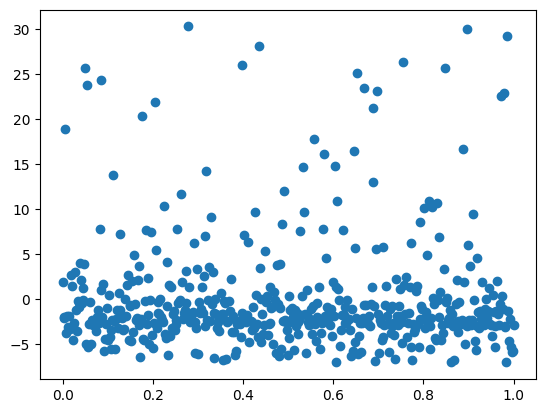

In [ ]:
x_1 = torch.rand(500)
x_2 = torch.rand(500)
x_3 = torch.rand(500)
y1 = 8 * (x_1- 0.5).pow(2)
y2 = (-8 * x_2 + 4).exp() / 10
y3 = 5* (-2* (2* x_3 - 1).pow(3)).exp()

y1 = y1 - y1.mean()
y2 = y2 -y2.mean()
y3 = y3 - y3.mean()

y = y1 + y2 + y3

y = y + 0.1 * torch.rand(y.size())
x = torch.linspace(0, 1, 500)


x_1 = torch.unsqueeze(x_1, dim=1)
x_2 = torch.unsqueeze(x_2, dim=1)
x_3 = torch.unsqueeze(x_3, dim=1)

y = torch.unsqueeze(y, dim=1)

plt.scatter(x.data.numpy(), y.data.numpy())
plt.show()

In [ ]:
class Model(nn.Module):
  def __init__(self, in_features, out_features):
    super(Model, self).__init__()

    self.layer1 = BayesLinear(in_features = in_features, out_features=100)
    self.activation = nn.ReLU()
    self.layer2 = BayesLinear(in_features=100, out_features= out_features)

  def forward(self, x):

    kl_sum = 0

    out, kl = self.layer1(x)
    kl_sum += kl
    out = self.activation(out)

    out, kl = self.layer2(out)

    kl_sum += kl

    return out, kl_sum


class BayesFeature(nn.Module):
  def __init__(self, in_features, out_features):
    super(BayesFeature, self).__init__()

    self.layer1 = nn.Linear(in_features = in_features, out_features=100)
    self.layer2 = nn.Linear(in_features = 100, out_features= 100)
    self.layer3 = nn.Linear(in_features = 100, out_features= out_features)
    self.activation = nn.ReLU()

  def forward(self, x):

    #kl_sum = 0

    out = self.layer1(x)
    #kl_sum += kl
    out = self.activation(out)

    out= self.layer2(out)
    #kl_sum += kl
    out = self.activation(out)

    out = self.layer3(out)
    #kl_sum += kl



    return out




class BayesNAM(nn.Module):
  def __init__(self,
                n_features,
                shallow_units: int,   # number of neurons in first layer
                hidden_units = [],  # tuple of numbers of hidden units
                activation = nn.ReLU(),
                return_output_lis = False
                ):
      super().__init__()

      self.shallow_units = shallow_units
      self.hidden_units = hidden_units
      self.activation = activation

      self.n_features = n_features
      self.return_output_lis = return_output_lis

      self.feature_nn_one = Model(1, 1)
      self.feature_nn_two = Model(1, 1)
      self.feature_nn_three = Model(1, 1)

      self.bias = nn.Parameter(torch.zeros(1))   #does the bias need a prior?

  def forward(self, f1,f2,f3):
    eta = self.bias
    output_lis = []
    kl_total = 0

    out_1, kl = self.feature_nn_one(f1)
    kl_total += kl
    #output_lis.append(out)

    out_2, kl = self.feature_nn_two(f2)
    kl_total += kl
    #output_lis.append(out)

    out_3, kl = self.feature_nn_three(f3)
    kl_total += kl
    #output_lis.append(out)

    # print(output_lis)

    #result = output_lis[0][0] + output_lis[1][0] + output_lis[2][0]

    #print(f'output_list result: {result}')


    #conc_out = torch.cat(output_lis, dim=-1)
    #out = torch.sum(conc_out, dim=-1) + self.bias

    out = out_1 + out_2 + out_3 + self.bias

    return out, kl_total



In [ ]:
test_feature = BayesNAM(1, 1)

In [ ]:
mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(test_feature.parameters(), lr=0.01)

In [ ]:
kl_weight = 0.01

In [ ]:
for step in range(20000):

    pre, kl = test_feature(x_1, x_2, x_3)

    mse = mse_loss(pre, y)
    cost = mse + kl * kl_weight


    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

print('- MSE : %2.2f, KL : %2.2f' % (mse.item(), kl.item()))

- MSE : 0.38, KL : 168.38


In [ ]:
x_test = torch.linspace(0, 1, 500)
y_1_test = 8 * (x_test- 0.5).pow(2)
y_2_test = (-8 * x_test + 4).exp() / 10
y_3_test = 5* (-2* (2* x_test - 1).pow(3)).exp()

x_test = torch.unsqueeze(x_test, dim=1)
y_1_test = torch.unsqueeze(y_1_test, dim=1)
y_2_test = torch.unsqueeze(y_2_test, dim=1)
y_3_test = torch.unsqueeze(y_3_test, dim=1)


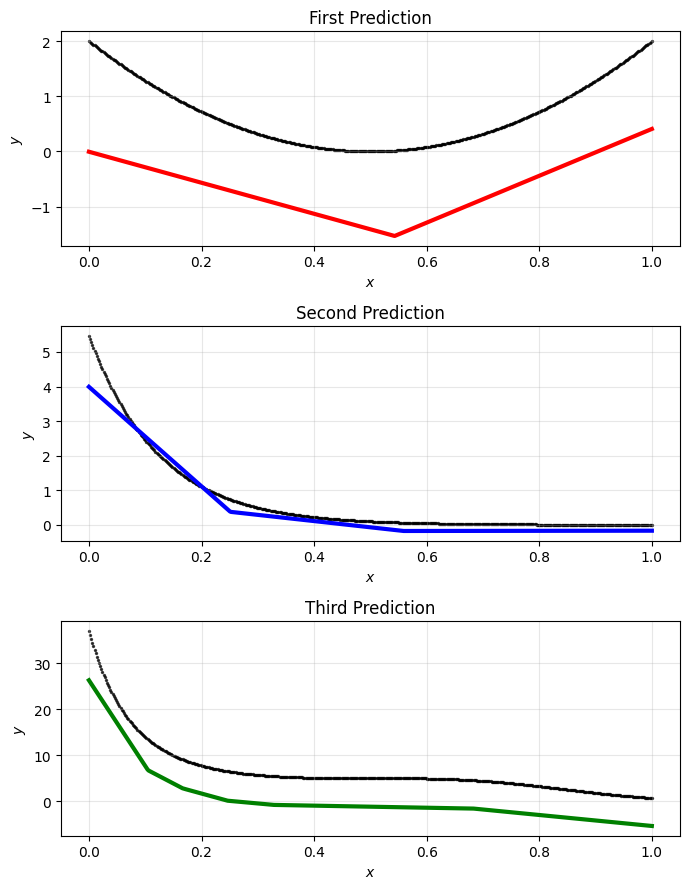

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(7, 9))

# First subplot
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$y$')
axes[0].scatter(x_test.data.numpy(), y_1_test.data.numpy(), color='k', s=2, alpha=0.7)
y_predict_1, _ = test_feature.feature_nn_one(x_test)
axes[0].plot(x_test.data.numpy(), y_predict_1.data.numpy(), 'r-', linewidth=3)
axes[0].set_title('First Prediction')
axes[0].grid(True, alpha=0.3)

# Second subplot
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$y$')
axes[1].scatter(x_test.data.numpy(), y_2_test.data.numpy(), color='k', s=2, alpha=0.7)
y_predict_2, _ = test_feature.feature_nn_two(x_test)
axes[1].plot(x_test.data.numpy(), y_predict_2.data.numpy(), 'b-', linewidth=3)
axes[1].set_title('Second Prediction')
axes[1].grid(True, alpha=0.3)

# Third subplot
axes[2].set_xlabel(r'$x$')
axes[2].set_ylabel(r'$y$')
axes[2].scatter(x_test.data.numpy(), y_3_test.data.numpy(), color='k', s=2, alpha=0.7)
y_predict_3, _ = test_feature.feature_nn_three(x_test)
axes[2].plot(x_test.data.numpy(), y_predict_3.data.numpy(), 'g-', linewidth=3)
axes[2].set_title('Third Prediction')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model better (hopefully)

In [ ]:
device = 'cuda'

In [ ]:
def create_synthetic_table_normal_response(function_list, noise_variance=1, n_datapoints= 10000, x_min=0, x_max=1, equally_spaced=True):
    """
    Create synthetic tabular data with the functions given
    such that the response y is given as y = f_1(x_1) + f_2(x_2) + ... + f_k(x_k) + eps for eps ~ N(0, noise_variance)
    It plots individual graphs for each function in a single row.

    Params:
        function_list: List of functions [f_1, f_2, ..., f_k] to use for the response
        noise_variance: The variance of the added noise
        n_datapoints: Number of samples to generate
        x_min: Minimum x_value for each covariate
        x_max: Maximum x_value for each covariate
        equally_spaced: If True, use equally spaced covariates; otherwise, use random uniform covariates

    Returns:
        X: Matrix containing the training data, has shape n_datapoints x len(function_list)
        y: Response variable, generated as specified
    """
    # Generate covariates (X) based on the specified method
    if equally_spaced:
        X = np.repeat(np.linspace(x_min, x_max, n_datapoints).reshape(-1, 1), len(function_list), axis = 1)
    else:
        X = np.random.uniform(x_min, x_max, size=(n_datapoints, len(function_list)))

    # Initialize an array to store the response variable
    num_functions = len(function_list)
    Y = np.zeros((num_functions, n_datapoints))


    # Create subplots for each function



    # Generate response variable y based on the given functions and noise
    for i, func in enumerate(function_list):
        Y[i] = func(X[:, i])

    Y = Y - np.mean(Y, axis = 1).reshape(-1, 1)

    noise = np.random.normal(0, np.sqrt(noise_variance), size=n_datapoints)
    if num_functions > 1:
      fig, axs = plt.subplots(1, num_functions, figsize=(15, 5))
      for i, func in enumerate(function_list):
          axs[i].scatter(X[:, i], Y[i] + noise, s=5, label=f'f_{i+1} with noise')
          axs[i].scatter(X[:, i], Y[i], s=5, label=f'f_{i+1}', c = "red")
          axs[i].set_xlabel(f'x_{i+1}')
          axs[i].set_ylabel('y')
          axs[i].legend()

    else:
      fig, axs = plt.subplots(1, num_functions, figsize=(5, 5))
      axs.scatter(X[:, 0], Y[0] + noise, s=5, label=f'f_{1}')
      axs.set_xlabel(f'x_{1}')
      axs.set_ylabel('y')
      axs.legend()

    plt.tight_layout()
    plt.show()

    # Add Gaussian noise with the specified variance
    y_mean = np.sum(Y, axis = 0)


    y = y_mean + noise


    #fig, axs = plt.subplots(1, 2, figsize=(10,5))

    #axs[0].scatter(np.mean(X, axis = 1), y_mean, s=5, label=f'final result without noise')

    #axs[1].scatter(np.mean(X, axis = 1), y, s=5, label=f'final result with noise')
    #axs[1].scatter(np.mean(X, axis = 1), y_mean, s=1, c = "red")

    return X, y, Y, noise


In [ ]:
f1 = lambda x: x**2
f2 = lambda x: 2*x
f3 = lambda x: x**3 - x**2 #np.sin(2*np.pi*x)

DATA_FUNCTIONS = [f1, f2, f3]
N_FEATURES_TABULAR = len(DATA_FUNCTIONS)

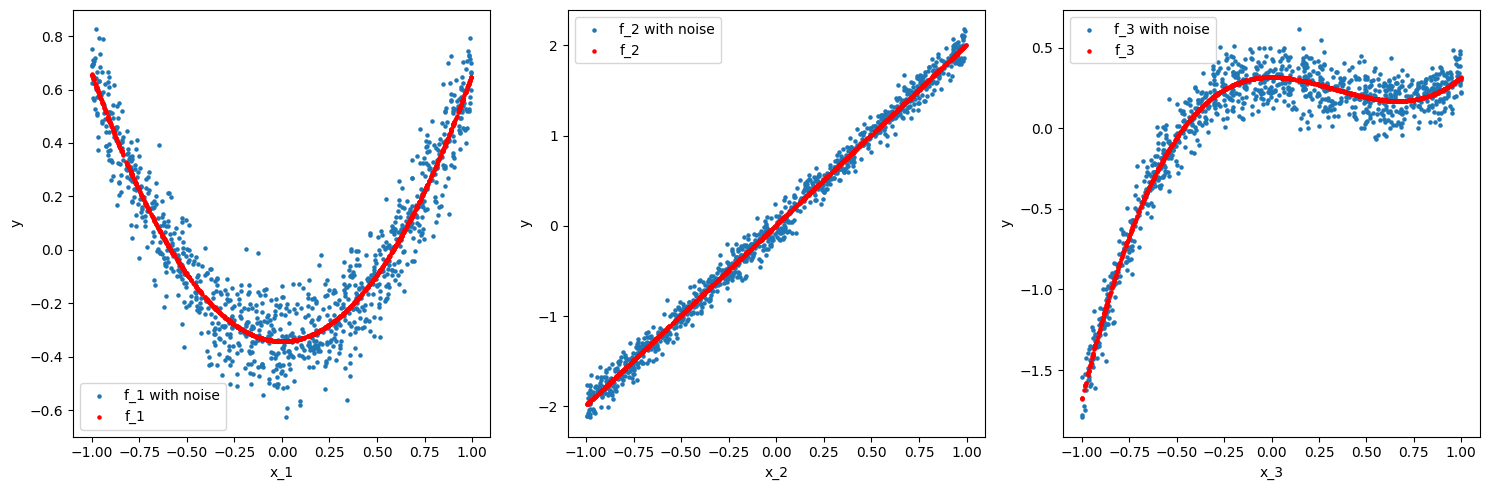

In [ ]:
X_tabular, y_response, Y_response, y_noise = create_synthetic_table_normal_response(DATA_FUNCTIONS, noise_variance = 1e-2, n_datapoints= 1000, x_min= -1, x_max= 1, equally_spaced = False)

In [ ]:
X_tabular[:,2].mean()

np.float64(0.006894946153470265)

In [ ]:
class CustomDataset_img_features(torch.utils.data.Dataset):
    """Face Landmarks dataset."""
    def __init__(self, feature_ten, label_ten, transforms=None):

        self.label_ten = label_ten
        self.feature_ten = feature_ten
        self.transforms = transforms

        assert len(label_ten) ==  len(feature_ten), "img_ten and and feature_ten and label ten must have equal size"

    def __len__(self):
      return len(self.feature_ten)

    def __getitem__(self, idx):
      feat = self.feature_ten[idx]
      y = self.label_ten[idx]

      return feat, y

In [ ]:
def train_test_split_features_images(features, targets, train_frac, val_frac, batch_size, transforms_val_test = None, transforms_train = None):

    tot_len = len(features)

    train_max_idx = int(tot_len*train_frac)
    val_max_idx = int(tot_len*val_frac) + train_max_idx

    train_features = features[:train_max_idx]
    train_y = targets[:train_max_idx]

    val_features = features[train_max_idx:val_max_idx]
    val_y = targets[train_max_idx:val_max_idx]

    test_features = features[val_max_idx:]
    test_y = targets[val_max_idx:]

    train_set = CustomDataset_img_features(train_features, train_y)
    val_set = CustomDataset_img_features(val_features, val_y)
    test_set = CustomDataset_img_features(test_features, test_y)

    train_loader = torch.utils.data.DataLoader(train_set, batch_size = batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_set, batch_size = batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size = batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

In [ ]:
train_loader, val_loader, test_loader = train_test_split_features_images(features = torch.tensor(X_tabular).float(),
                                                         targets = torch.tensor(y_response).float(),
                                                         train_frac = 0.7,
                                                         val_frac = 0.2,
                                                         batch_size = 100)

In [ ]:
class BayesFeature(nn.Module):
  def __init__(self, in_features, out_features):
    super(BayesFeature, self).__init__()

    self.layer1 = BayesLinear(in_features = in_features, out_features=20)
    self.layer2 = BayesLinear(in_features=20, out_features= 100)
    self.layer3 = BayesLinear(in_features=100, out_features= 100)
    self.activation = nn.LeakyReLU() #nn.LeakyReLU()
    self.layer4 = BayesLinear(in_features=100, out_features= out_features)

  def forward(self, x):

    kl_sum = 0

    out, kl = self.layer1(x)
    kl_sum += kl
    out = self.activation(out)

    out, kl = self.layer2(out)
    kl_sum += kl
    out = self.activation(out)

    out, kl = self.layer3(out)
    kl_sum += kl
    out = self.activation(out)

    out, kl = self.layer4(out)
    kl_sum += kl


    return out, kl_sum

class BayesNAM(nn.Module):
  def __init__(self,
                n_features,
                shallow_units: int,   # number of neurons in first layer
                hidden_units = [],  # tuple of numbers of hidden units
                activation = nn.ReLU(),
                return_output_lis = False
                ):
      super().__init__()

      self.shallow_units = shallow_units
      self.hidden_units = hidden_units
      self.activation = activation

      self.n_features = n_features
      self.return_output_lis = return_output_lis

      self.feature_nns = nn.ModuleList([
          Model(1, 1),
          Model(1, 1),
          Model(1, 1),
      ])

      #self.feature_nn_one = BayesFeature(1, 1)
      #self.feature_nn_two = BayesFeature(1, 1)
      #self.feature_nn_three = BayesFeature(1, 1)

      self.bias = nn.Parameter(torch.zeros(1))   #does the bias need a prior?

  def forward(self, f):

    eta = self.bias
    output_lis = []
    kl_total = 0

    for feature, mod in zip(f.T, self.feature_nns):

      feature = feature.unsqueeze(-1)
      ri, kl = mod(feature)
      kl_total += kl
      output_lis.append(ri)

    #out_1, kl = self.feature_nn_one(f[:,0].unsqueeze(-1))
    #kl_total += kl
    #output_lis.append(out_1)

    #out_2, kl = self.feature_nn_two(f[:,1].unsqueeze(-1))
    #kl_total += kl
    #output_lis.append(out_2)

    #out_3, kl = self.feature_nn_three(f[:,2].unsqueeze(-1))
    #kl_total += kl
    #output_lis.append(out_3)

    # print(output_lis)

    #result = output_lis[0][0] + output_lis[1][0] + output_lis[2][0]

    #print(f'output_list result: {result}')


    conc_out = torch.cat(output_lis, dim=-1)
    out = torch.sum(conc_out, dim=-1) + self.bias

    #out = out_1 + out_2 + out_3 + self.bias

    return out, kl_total


In [ ]:
x = torch.tensor(X_tabular[:,2]).float().unsqueeze(-1)

In [ ]:
y = torch.tensor(Y_response[2,:]).float().unsqueeze(-1)

In [ ]:
x = torch.linspace(0, 1, 500)
y = x.pow(2)

x = torch.unsqueeze(x, dim=1)
y = torch.unsqueeze(y, dim=1)

In [ ]:
y.shape

torch.Size([500, 1])

In [ ]:
x.shape

torch.Size([500, 1])

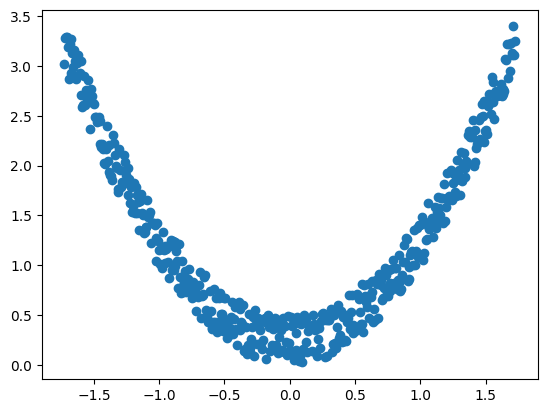

In [ ]:
x = torch.linspace(0, 1, 500)
x = (x - x.mean())/x.std()
y =  x.pow(2) + 0.5*torch.rand(x.size())
x = torch.unsqueeze(x, dim=1)
y = torch.unsqueeze(y, dim=1)

plt.scatter(x.data.numpy(), y.data.numpy())
plt.show()


In [ ]:
x.mean()

tensor(9.4652e-08)

In [ ]:
x.std()

tensor(1.)

In [ ]:
feature_test = BayesFeature(1,1)

In [ ]:
mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(feature_test.parameters(), lr=0.1)

In [ ]:
kl_weight = 0.01

In [ ]:
for step in range(3000):

    pre, kl = feature_test(x)

    mse = mse_loss(pre, y)
    cost = mse + kl * kl_weight


    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

print('- MSE : %2.2f, KL : %2.2f' % (mse.item(), kl.item()))

- MSE : 0.15, KL : 56.16


In [ ]:
x_test.shape

torch.Size([500, 1])

In [ ]:
x_test = torch.linspace(0, 1, 500)
x_test = (x_test -x_test.mean())/x_test.std()
y_test = x_test.pow(2) + 0.5*torch.rand(x_test.size())

x_test = torch.unsqueeze(x_test, dim=1)
y_test = torch.unsqueeze(y_test, dim=1)

In [ ]:
x_test.mean()

tensor(9.4652e-08)

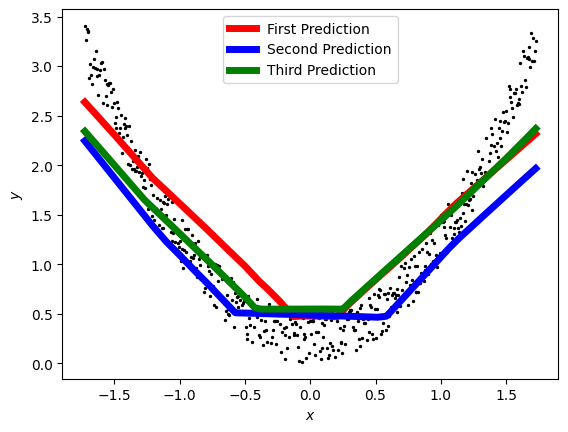

In [ ]:
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.scatter(x_test.data.numpy(), y_test.data.numpy(), color='k', s=2)

y_predict, _ = feature_test(x_test)
plt.plot(x_test.data.numpy(), y_predict.data.numpy(), 'r-', linewidth=5, label='First Prediction')

y_predict, _ = feature_test(x_test)
plt.plot(x_test.data.numpy(), y_predict.data.numpy(), 'b-', linewidth=5, label='Second Prediction')

y_predict, _ = feature_test(x_test)
plt.plot(x_test.data.numpy(), y_predict.data.numpy(), 'g-', linewidth=5, label='Third Prediction')

plt.legend()

plt.show()

In [ ]:
def train(model, optimizer, loss_fun, trainset, device, n_epochs, batch_size, n_samples, kl_weight = 0.1,  print_mod = 1):

    loss_lis = []
    overall_loss = []
    val_loss = []

    model = model.to(device)

    for epoch in range(n_epochs):

        for i, batch in enumerate(trainset):

            x, y = batch
            x = x.to(device)
            y = y.to(device)

            output = []
            kl_div = []

            for _ in range(n_samples):
                out, kl = model(x)
                output.append(out)
                kl_div.append(kl)


            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)

            #print(kl_loss)

            mean_pred = mean_pred.squeeze(-1)


            loss = loss_fun(mean_pred, y)
            scaled_kl = kl_loss * kl_weight
            loss += scaled_kl  #ELBO Loss add if loos_fun is negative log_likelihood

            #loss = loss_fun(out, y)
            #loss += kl * 0.1     # Why does this improve training so much? kl / batch_size and add sampling again


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_lis.append(loss.cpu().detach())

        if epoch % print_mod == 0:

            mean_loss = np.mean(np.array(loss_lis))
            overall_loss += mean_loss
            loss_lis = []

            #validation_loss = validate(model, valset, loss_fun, n_samples)

            #val_loss.append(validation_loss)


            print(f'Epoch nr {epoch}: mean_train_loss = {mean_loss}')
            #, , validation_loss =  {validation_loss}')

    print(kl_loss)

    return overall_loss


In [ ]:
test_two_feature = BayesNAM(1, 1)

In [ ]:
mse_loss_two = nn.MSELoss()
optimizer_two = torch.optim.AdamW(test_two_feature.parameters(), lr=0.1, weight_decay=1e-3)
#optimizer_two = torch.optim.Adam(test_two_feature.parameters(), lr=0.1)

try add kl weight term, reduce sampling, scaling inputs ( also from to -1 1) , change initialization from network, try dropout, feature dropout

In [ ]:
com_loss = train(model = test_two_feature, optimizer = optimizer_two, loss_fun = mse_loss_two, trainset = train_loader, device = device, n_epochs = 1000, kl_weight= 0.01, batch_size = 128, n_samples = 10, print_mod = 10)

Epoch nr 0: mean_train_loss = 5261.10595703125
Epoch nr 10: mean_train_loss = 19.04701805114746
Epoch nr 20: mean_train_loss = 2.1461827754974365
Epoch nr 30: mean_train_loss = 1.368109107017517
Epoch nr 40: mean_train_loss = 1.1108191013336182
Epoch nr 50: mean_train_loss = 0.8621983528137207
Epoch nr 60: mean_train_loss = 0.785484254360199
Epoch nr 70: mean_train_loss = 0.7724606394767761
Epoch nr 80: mean_train_loss = 0.6423528790473938
Epoch nr 90: mean_train_loss = 0.6090893149375916
Epoch nr 100: mean_train_loss = 0.5499909520149231
Epoch nr 110: mean_train_loss = 0.5122707486152649
Epoch nr 120: mean_train_loss = 0.46627354621887207
Epoch nr 130: mean_train_loss = 0.4427356719970703
Epoch nr 140: mean_train_loss = 0.42144569754600525
Epoch nr 150: mean_train_loss = 0.4265367090702057
Epoch nr 160: mean_train_loss = 0.3934178054332733
Epoch nr 170: mean_train_loss = 0.40283697843551636
Epoch nr 180: mean_train_loss = 0.4072869122028351
Epoch nr 190: mean_train_loss = 0.4021983146

In [ ]:
x_test = torch.linspace(-1, 1, 1000)
y_1_test = x_test.pow(2)
y_2_test = 2*x_test
y_3_test = x_test.pow(3) - x_test.pow(2)


x_test = torch.unsqueeze(x_test, dim=1)
y_1_test = torch.unsqueeze(y_1_test, dim=1)
y_2_test = torch.unsqueeze(y_2_test, dim=1)
y_3_test = torch.unsqueeze(y_3_test, dim=1)

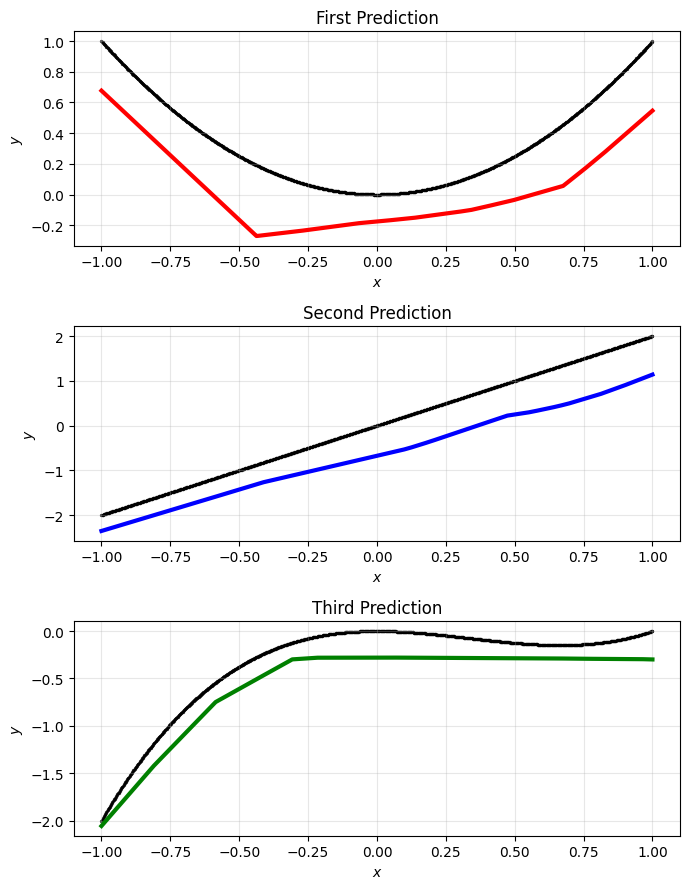

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(7, 9))

# First subplot
axes[0].set_xlabel(r'$x$')
axes[0].set_ylabel(r'$y$')
axes[0].scatter(x_test.data.numpy(), y_1_test.data.numpy(), color='k', s=2, alpha=0.7)
y_predict_1, _ = test_two_feature.feature_nns[0](x_test.to(device))
axes[0].plot(x_test.data.numpy(), y_predict_1.cpu().data.numpy(), 'r-', linewidth=3)
axes[0].set_title('First Prediction')
axes[0].grid(True, alpha=0.3)

# Second subplot
axes[1].set_xlabel(r'$x$')
axes[1].set_ylabel(r'$y$')
axes[1].scatter(x_test.data.numpy(), y_2_test.data.numpy(), color='k', s=2, alpha=0.7)
y_predict_2, _ = test_two_feature.feature_nns[1](x_test.to(device))
axes[1].plot(x_test.data.numpy(), y_predict_2.cpu().data.numpy(), 'b-', linewidth=3)
axes[1].set_title('Second Prediction')
axes[1].grid(True, alpha=0.3)

# Third subplot
axes[2].set_xlabel(r'$x$')
axes[2].set_ylabel(r'$y$')
axes[2].scatter(x_test.data.numpy(), y_3_test.data.numpy(), color='k', s=2, alpha=0.7)
y_predict_3, _ = test_two_feature.feature_nns[2](x_test.to(device))
axes[2].plot(x_test.data.numpy(), y_predict_3.cpu().data.numpy(), 'g-', linewidth=3)
axes[2].set_title('Third Prediction')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
y_predict_3

tensor([[-0.2985],
        [-0.2985],
        [-0.2985],
        ...,
        [-0.2911],
        [-0.2911],
        [-0.2911]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [ ]:
# @title
def validate(model, val_loader, loss_fun, n_samples):

    val_loss = []

    model.eval()

    with torch.no_grad():
        for i, batch in enumerate(val_loader):

            input, target = batch

            target = target.to(device)
            input = input.to(device)

            output = []
            kl_div = []

            for sample in range(n_samples):
                out, kl = model(input)
                output.append(out)
                kl_div.append(kl)

            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)
            log_lik_loss = loss_fun(mean_pred, target)
            loss = log_lik_loss + kl_loss
            val_loss.append(loss.cpu())

        mean_loss = np.mean(np.array(val_loss))

    return mean_loss



def train(model, optimizer, loss_fun, trainset, device, n_epochs, batch_size, n_samples, print_mod = 1):

    loss_lis = []
    overall_loss = []
    val_loss = []

    model = model.to(device)

    for epoch in range(n_epochs):

        for i, batch in enumerate(trainset):

            x, y = batch
            x = x.to(device)
            y = y.to(device)

            output = []
            kl_div = []

            for _ in range(n_samples):
                out, kl = model(x)
                output.append(out)
                kl_div.append(kl)

            # out, kl = model(x)


            mean_pred = torch.mean(torch.stack(output), dim = 0)
            kl_loss = torch.mean(torch.stack(kl_div), dim = 0)

            #print(kl_loss)

            loss = loss_fun(mean_pred, y)
            scaled_kl = kl_loss/batch_size
            loss += scaled_kl  #ELBO Loss add if loos_fun is negative log_likelihood

            #loss = loss_fun(out, y)
            #loss += kl * 0.1     # Why does this improve training so much? kl / batch_size and add sampling again


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_lis.append(loss.cpu().detach())

        if epoch % print_mod == 0:

            mean_loss = np.mean(np.array(loss_lis))
            overall_loss += mean_loss
            loss_lis = []

            #validation_loss = validate(model, valset, loss_fun, n_samples)

            #val_loss.append(validation_loss)


            print(f'Epoch nr {epoch}: mean_train_loss = {mean_loss}')
            #, , validation_loss =  {validation_loss}')

    return overall_loss




def sample(model, n_samples, testloader):

  model.eval()
  mean_pred_list = []
  std_list = []

  with torch.no_grad():

    for i, batch in enumerate(testloader):

      output_mc = []

      data, target = batch

      data = data.to(device)

      for _ in range(n_samples):
        out, _ = model.forward(data)
        output_mc.append(out)

      output = torch.stack(output_mc)

      mean_pred_batch = torch.mean(output, dim = 0)
      std_batch = torch.sqrt(torch.var(output, dim = 0))
      mean_pred_list.append(mean_pred_batch)
      std_list.append(std_batch)


  return mean_pred_list, std_list



def sample_features(model, n_features, n_samples, data):

  mean_outputs = np.zeros((len(data), n_features))
  standard_variations = np.zeros((len(data), n_features))

  bias = model.bias.item()

  max_fun = lambda x: np.quantile(x, q = 1)
  min_fun = lambda x: np.quantile(x, q = 0)


   # sample individual features
  for i in range(n_features):

    feat_model = model.feature_nns[i]

    x_vals_compute = data[:, i]

    valid_idx = (x_vals_compute >= min_fun(x_vals_compute)) & (x_vals_compute <= max_fun(x_vals_compute))

    x_vals_compute = x_vals_compute[valid_idx]

    min_compute = min(x_vals_compute)
    max_compute = max(x_vals_compute)
    range_compute = np.linspace(min_compute, max_compute, 10000)

    bayes_feature_nn = feat_model.eval()

    with torch.no_grad():

      output_mc = []

      model_input = torch.tensor(range_compute).to(device).reshape(-1, 1).float()

      for _ in range(n_samples):
        out, _ = feat_model.forward(model_input)
        out = out + bias
        output_mc.append(out)

      output = torch.stack(output_mc)

      mean_prediction = torch.mean(output, dim = 0)
      std = torch.sqrt(torch.var(output, dim = 0))

      mean_outputs[:, i] = mean_prediction.cpu().numpy().squeeze()
      standard_variations[:, i] = std.cpu().numpy().squeeze()

  return mean_outputs, standard_variations


In [ ]:
# @title
class BayesFeature(nn.Module):

  def __init__(self,
                 shallow_units: int,   # number of neurons in first layer
                 hidden_units = [],  # tuple of numbers of hidden units
                 activation = nn.ReLU(),
                 ):
        super().__init__()

        # Define Layers
        self.layers = nn.ModuleList([
            BayesLinear(shallow_units if i == 0 else hidden_units[i - 1], hidden_units[i])
            for i in range(len(hidden_units))
        ])

        self.output_layer = BayesLinear(hidden_units[-1], 1)

        self.activation = activation


  def forward(self, x):
    kl_sum = 0
    for i, layer in enumerate(self.layers):
      x, kl  = layer(x)
      kl_sum += kl
      x = self.activation(x)
    x, kl = self.output_layer(x)
    kl_sum += kl
    return x, kl





class BayesNAM(nn.Module):
  def __init__(self,
                n_features,
                shallow_units: int,   # number of neurons in first layer
                hidden_units = [],  # tuple of numbers of hidden units
                activation = nn.ReLU(),
                return_output_lis = False
                ):
      super().__init__()

      self.shallow_units = shallow_units
      self.hidden_units = hidden_units
      self.activation = activation

      self.n_features = n_features
      self.return_output_lis = return_output_lis

      self.feature_nns = nn.ModuleList([
            BayesFeature(shallow_units=shallow_units,
                      hidden_units=hidden_units,
                      activation=activation)
            for i in range(n_features)
        ])

      self.bias = nn.Parameter(torch.zeros(1))   #does the bias need a prior?

  def forward(self, f):
    eta = self.bias
    output_lis = []
    kl_total = 0
    for feature, mod in zip(f.T, self.feature_nns):   #Kullback Leibler is additive include proof
      feature = feature.unsqueeze(-1)
      out, kl = mod(feature)
      kl_total += kl
      output_lis.append(out)

    if self.return_output_lis:
      return output_lis

    else:
       conc_out = torch.cat(output_lis, dim=-1)
       out = torch.sum(conc_out, dim=-1) + self.bias

       return out, kl_total


In [ ]:
# @title
class CustomDataset_img_features(torch.utils.data.Dataset):
    """Face Landmarks dataset."""
    def __init__(self, feature_ten, label_ten):

        self.label_ten = label_ten
        self.feature_ten = feature_ten

        assert len(label_ten) ==  len(feature_ten), "img_ten and and feature_ten and label ten must have equal size"

    def __len__(self):
      return len(self.feature_ten)

    def __getitem__(self, idx):

      feat = self.feature_ten[idx]
      y = self.label_ten[idx]

      return feat, y

In [ ]:
# @title
def train_test_split_features_images(features, targets, train_frac, val_frac, batch_size):

    tot_len = len(features)

    train_max_idx = int(tot_len*train_frac)
    val_max_idx = int(tot_len*val_frac) + train_max_idx

    train_features = features[:train_max_idx]
    train_y = targets[:train_max_idx]

    val_features = features[train_max_idx:val_max_idx]
    val_y = targets[train_max_idx:val_max_idx]

    test_features = features[val_max_idx:]
    test_y = targets[val_max_idx:]

    train_set = CustomDataset_img_features(train_features, train_y)
    val_set = CustomDataset_img_features(val_features, val_y)
    test_set = CustomDataset_img_features(test_features, test_y)

    train_loader = torch.utils.data.DataLoader(train_set, batch_size = batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(val_set, batch_size = batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size = batch_size, shuffle=True)

    return train_loader, val_loader, test_loader

- MSE : 9.12, KL : 198.43


In [ ]:
X_test = torch.rand(500, 3)

In [ ]:
y1_test = 8*(X_test[:,0] -0.5)**2 + 0.1 * torch.rand(x.size())
y2_test = np.exp(-8* X_test[:,1] +4)/10 + 0.1 * torch.rand(x.size())
y3_test = 5*np.exp(-2*(2* X_test[:,2] -1)**2) + 0.1 * torch.rand(x.size())

/tmp/ipython-input-1436411795.py:2: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y2_test = np.exp(-8* X_test[:,1] +4)/10 + 0.1 * torch.rand(x.size())
/tmp/ipython-input-1436411795.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y3_test = 5*np.exp(-2*(2* X_test[:,2] -1)**2) + 0.1 * torch.rand(x.size())


In [ ]:
y1_test = torch.unsqueeze(y1_test, dim=1)
y2_test = torch.unsqueeze(y2_test, dim=1)
y3_test = torch.unsqueeze(y3_test, dim=1)

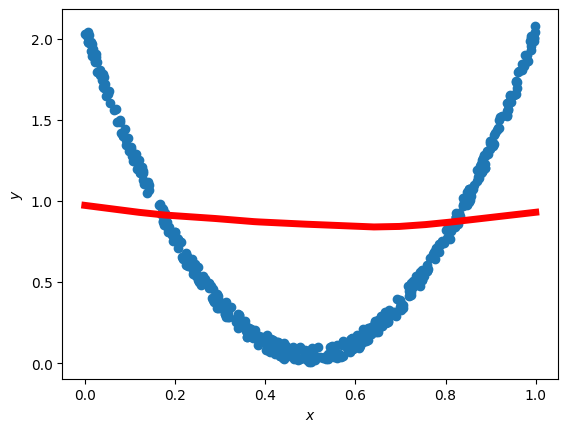

In [ ]:
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.scatter(X_test[:,0].unsqueeze(-1).data.numpy(), y1_test.data.numpy())

y_predict, _ = test_feature.feature_nn_one(torch.linspace(0, 1, 500).unsqueeze(-1))
plt.plot(torch.linspace(0, 1, 500).unsqueeze(-1).data.numpy(), y_predict.data.numpy(), 'r-', linewidth=5, label='First Prediction')

In [ ]:
single_feature = Model(1, 1)

In [ ]:
mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(single_feature.parameters(), lr=0.01)

In [ ]:
x_single_training = torch.linspace(0, 1, 500).unsqueeze(1)
y1_single_training = 8*(x_single_training - 0.5)**2 + 0.1 * torch.randn(x_single_training.size())

In [ ]:
for step in range(1000):

    pre, kl = single_feature(x_single_training)

    mse = mse_loss(pre, y1_single_training)
    cost = mse + kl_weight*kl

    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

print('- MSE : %2.2f, KL : %2.2f' % (mse.item(), kl.item()))

- MSE : 1.08, KL : 4.87


In [ ]:
x_test = torch.linspace(0, 1, 500).unsqueeze(1)
y_true = 8*(x_test - 0.5)**2

In [ ]:
single_feature.eval()  # Set to evaluation mode
with torch.no_grad():
    y_predict, _ = single_feature(x_test)

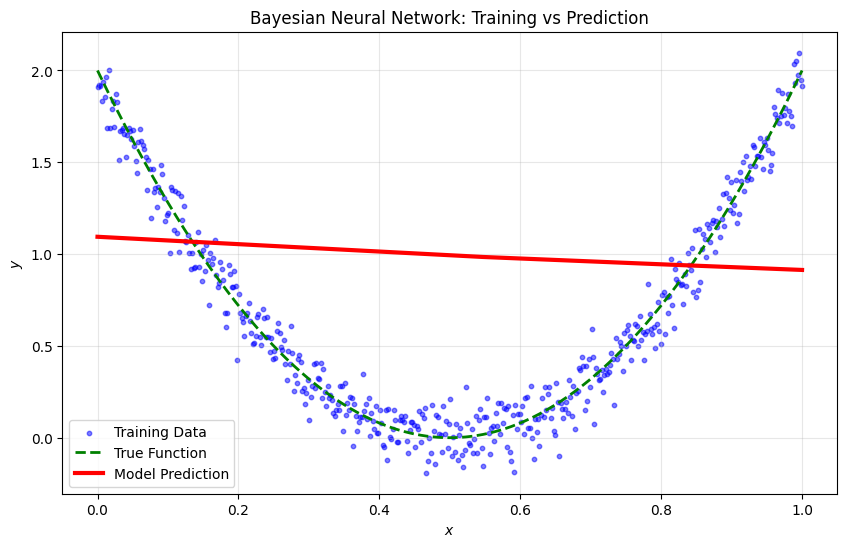

In [ ]:
plt.figure(figsize=(10, 6))
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

# Plot training data
plt.scatter(x_single_training.numpy(), y1_single_training.numpy(),
           alpha=0.5, color='blue', s=10, label='Training Data')

# Plot true function
plt.plot(x_test.numpy(), y_true.numpy(), 'g--', linewidth=2, label='True Function')

# Plot prediction
plt.plot(x_test.numpy(), y_predict.numpy(), 'r-', linewidth=3, label='Model Prediction')

plt.legend()
plt.title('Bayesian Neural Network: Training vs Prediction')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
test_pred, _  = test_feature(x_test_1_plot)

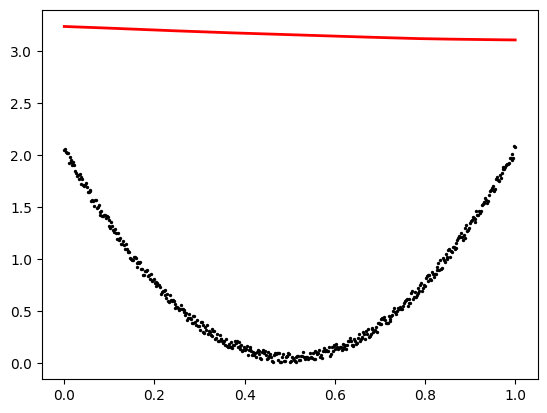

In [ ]:
plt.scatter(x_test_1_plot.data.numpy(), y1_test_plot.data.numpy(), color='k', s=2)
plt.plot(x_test_1_plot.data.numpy(), test_pred.data.numpy(), 'r-', linewidth=2, label='First Prediction')

In [ ]:
model = BayesNAM(n_features = 3, shallow_units = 1, hidden_units=(100, 100, 100)) #check why 20 didnt work

In [ ]:
mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
kl_weight = 0.1

In [ ]:
for step in range(1000):

    pre, kl = model(X)
    mse = mse_loss(pre, y1)
    cost = mse + kl_weight*kl

    optimizer.zero_grad()
    cost.backward()
    optimizer.step()

print('- MSE : %2.2f, KL : %2.2f' % (mse.item(), kl.item()))

- MSE : 0.70, KL : 45.65


In [ ]:
X_test = torch.linspace(0, 1, 500).unsqueeze(1).repeat(1, 3)

y1_test = 8*(X_test[:, 0]-0.5)**2 + 0.1 * torch.rand(x.size())
y2_test = np.exp(-8*X_test[:,0] +4)/10 + 0.1 * torch.rand(x.size())
y3_test = 5*np.exp(-2*(2* X_test[:,0] -1)**2) + 0.1 * torch.rand(x.size())

/tmp/ipython-input-2296852488.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y2_test = np.exp(-8*X_test[:,0] +4)/10 + 0.1 * torch.rand(x.size())
/tmp/ipython-input-2296852488.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  y3_test = 5*np.exp(-2*(2* X_test[:,0] -1)**2) + 0.1 * torch.rand(x.size())


In [ ]:
y_test = torch.stack((y1_test,y2_test,y3_test))
y_test = torch.sum((y_test), dim= 0)

In [ ]:
x_test_1_plot = torch.unsqueeze(X_test[:, 0], dim=1)
y1_test_plot = torch.unsqueeze(y1_test, dim=1)

x_test_2_plot = torch.unsqueeze(X_test[:, 1], dim=1)
y2_test_plot = torch.unsqueeze(y2_test, dim=1)


x_test_3_plot = torch.unsqueeze(X_test[:, 2], dim=1)
y3_test_plot = torch.unsqueeze(y3_test, dim=1)

In [ ]:
y_predict_1, _ = model.feature_nn_one(x_test_1_plot)
y_predict_2, _ = model.feature_nn_two(x_test_2_plot)
y_predict_3, _ = model.feature_nn_three(x_test_3_plot)

In [ ]:
y_predict, _ = model(X_test)

In [ ]:
y_test= torch.unsqueeze(y_test, dim=1)

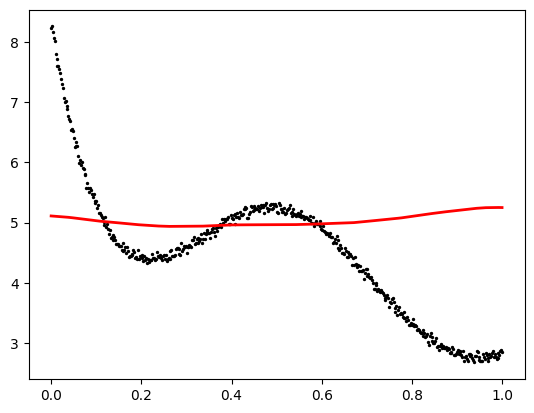

In [ ]:
plt.scatter(x_test_1_plot.data.numpy(), y_test.data.numpy(), color='k', s=2)
plt.plot(x_test_1_plot.data.numpy(), y_predict.data.numpy(), 'r-', linewidth=2, label='First Prediction')

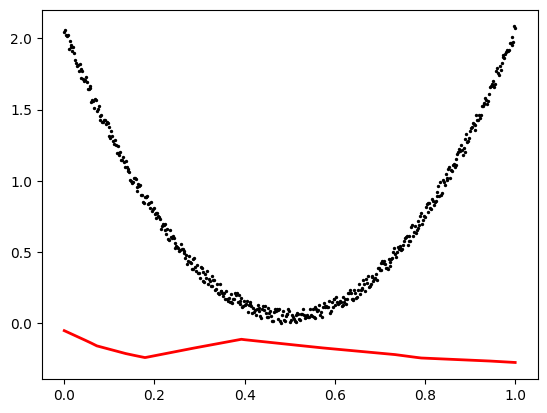

In [ ]:
plt.scatter(x_test_1_plot.data.numpy(), y1_test_plot.data.numpy(), color='k', s=2)
plt.plot(x_test_1_plot.data.numpy(), y_predict_1.data.numpy(), 'r-', linewidth=2, label='First Prediction')

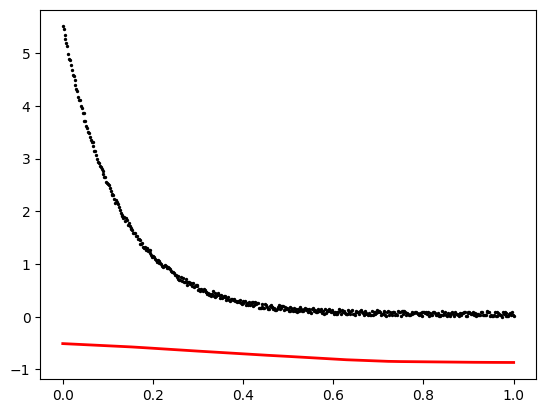

In [ ]:
plt.scatter(x_test_2_plot.data.numpy(), y2_test_plot.data.numpy(), color='k', s=2)
plt.plot(x_test_2_plot.data.numpy(), y_predict_2.data.numpy(), 'r-', linewidth=2, label='First Prediction')

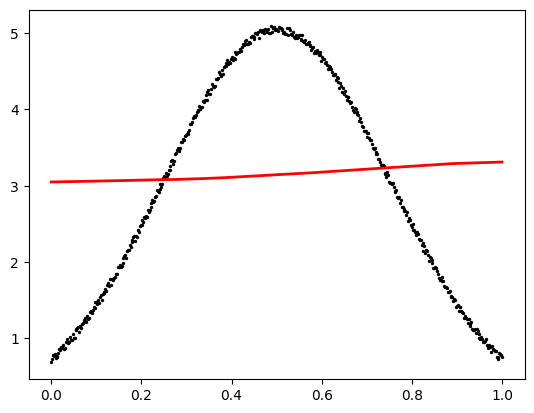

In [ ]:
plt.scatter(x_test_3_plot.data.numpy(), y3_test_plot.data.numpy(), color='k', s=2)
plt.plot(x_test_3_plot.data.numpy(), y_predict_3.data.numpy(), 'r-', linewidth=2, label='First Prediction')

In [ ]:
n_features = 4

In [ ]:
plus_error = [mean_outputs[:,i] + 2 * standard_variations[:,i] for i in range(n_features)]

In [ ]:
minus_error = [mean_outputs[:,i] - 2 * standard_variations[:,i] for i in range(n_features)]

In [ ]:
plus_error[0]

array([4.25994101, 4.25991067, 4.25988033, ..., 3.59032667, 3.5902741 ,
       3.59022141])

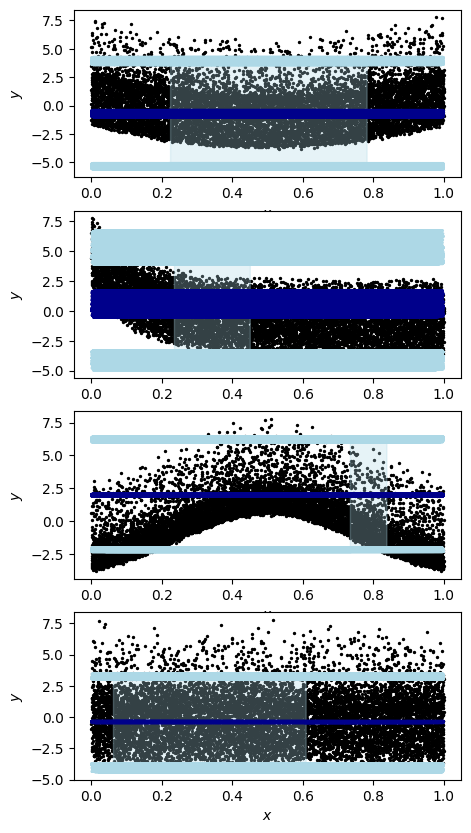

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(5, 10))


for i in range(n_features):

  ax = axes[i]

  ax.set_xlabel(r'$x$')
  ax.set_ylabel(r'$y$')

  ax.scatter(X_tabular_test[:,i], y_response_test, color='k', s=2)

  # Dark blue for mean prediction
  ax.plot(X_tabular_test[:,i], mean_outputs[:,i], color='darkblue', linewidth=2, label='Mean Prediction')

  # Light blue for error bounds
  ax.plot(X_tabular_test[:,i], plus_error[i], color='lightblue', linewidth=2, label='Upper Bound')
  ax.plot(X_tabular_test[:,i], minus_error[i], color='lightblue', linewidth=2, label='Lower Bound')

  # Light blue shaded area between error bounds
  ax.fill_between(X_tabular_test[:,i], plus_error[i].squeeze(), minus_error[i].squeeze(), color='lightblue', alpha=0.3, label='Confidence Interval')
